# TECH CHALLENGE FASE 1 - EDA

## Entendimento do negócio

● **Qual problema de negócio está sendo resolvido?**

A reatividade operacional, ou seja, a empresa perde clientes e dinheiro porque só descobre a insatisfação quando o dano (churn) já é iminente ou irreversível.


● **Por que o NPS é importante para um e-commerce?**

O NPS é importante para medir a satisfação do cliente, fazer com que ele volte a comprar no e-commerce e ainda seja um promotor da empresa, ou seja, indicando aquele e-commerce para outras pessoas. Além disso, é financeiramente mais barato recuperar um "Neutro” do que um "Detrator que teve um produto entregue com atraso por exemplo

● **Quais áreas poderiam se beneficiar desses insights?**

Correlacionando as variáveis que temos nos nossos dados, podemos entender onde as falhas estão acontecendo.
Por exemplo:
Teve estoque? Se faltou, a área de compras não poderia ter uma previsibilidade melhor de demandas?
Teve atraso? A área de logística, não poderia ter melhor planejamento nas entregas?
Teve problemas e o atendimento foi demorado? Podemos tentar antecipar problemas e ter um contato proativo do time de atendimento.


**Passo 1:** Import do arquivo desafio_nps_fase_1.csv



In [ ]:
%pip install -r ~/postech/1IAST-TechChallenge/requirements.txt

In [34]:
#Libs que serão utilizadas no projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import pandas_gbq as bpd
from google.cloud import bigquery
from google.oauth2 import service_account


In [ ]:
import os

path = "/home/vanessahay/postech/1IAST-TechChallenge/Notebook"

os.chdir(path)

print(f"Diretório atual: {os.getcwd()}")

In [36]:
#Para buscar dados no BigQuery
PROJECT_ID = "vanehay"
DATASET_ID = "1IAST"
TABLE_NAME = "desafio_nps_fase_1"
table_ref = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}"
df_full_nps = bpd.read_gbq(table_ref)
df_full_nps = pd.DataFrame(df_full_nps)

Downloading: 100%|██████████|


In [37]:
# Carregamento de dados utilizando a biblioteca pandas
df_full_nps = pd.read_csv('../Data/desafio_nps_fase_1.csv', sep=None, engine='python')
df_full_nps.head()

print("Quantidade de linhas e colunas do dataframe:")
print(df_full_nps.shape)



Quantidade de linhas e colunas do dataframe:
(2500, 19)


In [38]:
print("Tipos de cada coluna")
print(df_full_nps.dtypes)

Tipos de cada coluna
customer_id                    Int64
customer_age                   Int64
customer_region               object
customer_tenure_months         Int64
order_id                       Int64
order_value                  float64
items_quantity                 Int64
discount_value               float64
payment_installments           Int64
delivery_time_days             Int64
delivery_delay_days            Int64
freight_value                float64
delivery_attempts              Int64
customer_service_contacts      Int64
resolution_time_days           Int64
nps_score                    float64
repeat_purchase_30d            Int64
complaints_count               Int64
csat_internal_score          float64
dtype: object


In [39]:
print("Valores nulos")
df_full_nps.isnull().sum()

Valores nulos


,0
customer_id,0
customer_age,0
customer_region,0
customer_tenure_months,0
order_id,0
order_value,0
items_quantity,0
discount_value,0
payment_installments,0
delivery_time_days,0


In [40]:
print("Colunas carregadas no dataframe")
df_full_nps.columns

Colunas carregadas no dataframe


Index(['customer_id', 'customer_age', 'customer_region',
       'customer_tenure_months', 'order_id', 'order_value', 'items_quantity',
       'discount_value', 'payment_installments', 'delivery_time_days',
       'delivery_delay_days', 'freight_value', 'delivery_attempts',
       'customer_service_contacts', 'resolution_time_days', 'nps_score',
       'repeat_purchase_30d', 'complaints_count', 'csat_internal_score'],
      dtype='object')

In [41]:
print("Resumo estatístico do dataframe")
df_full_nps.describe().round(2)

Resumo estatístico do dataframe


,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score
count,2500.0,2500.0,2500.0,2500.0,2500.00,2500.0,2500.00,2500.0,2500.0,2500.0,2500.00,2500.0,2500.0,2500.0,2500.00,2500.0,2500.0,2500.00
mean,1250.5,43.4,61.32,51250.5,434.26,3.47,29.75,6.0,8.02,2.19,38.22,2.01,1.52,5.49,4.38,0.09,4.15,2.94
std,721.83,14.89,34.48,721.83,289.77,1.69,29.23,3.16,3.77,1.45,12.08,0.82,1.23,3.46,2.51,0.28,1.78,2.38
min,1.0,18.0,1.0,50001.0,7.76,1.0,0.02,1.0,2.0,0.0,2.62,1.0,0.0,0.0,0.00,0.0,0.0,0.00
25%,625.75,31.0,31.0,50625.75,220.24,2.0,8.88,3.0,5.0,1.0,29.93,1.0,1.0,2.0,2.60,0.0,3.0,0.70
50%,1250.5,43.0,62.0,51250.5,375.52,3.0,20.94,6.0,8.0,2.0,38.50,2.0,1.0,6.0,4.40,0.0,4.0,2.80
75%,1875.25,56.0,91.0,51875.25,577.29,5.0,40.83,9.0,11.0,3.0,46.27,3.0,2.0,8.0,6.10,0.0,5.0,4.80
max,2500.0,69.0,119.0,52500.0,1983.81,6.0,230.33,11.0,14.0,8.0,76.13,3.0,7.0,11.0,10.00,1.0,11.0,10.00


**Passo 2** Criação das variáveis de negócio

O NPS (Net Promoter Score) é uma métrica de fidelidade e satisfação do cliente que avalia a probabilidade de recomendação de uma empresa, produto ou serviço, numa escala de 0 a 10. Ele classifica clientes em promotores (9-10), neutros (7-8) ou detratores (0-6), ajudando a identificar a saúde do negócio e oportunidades de melhoria.

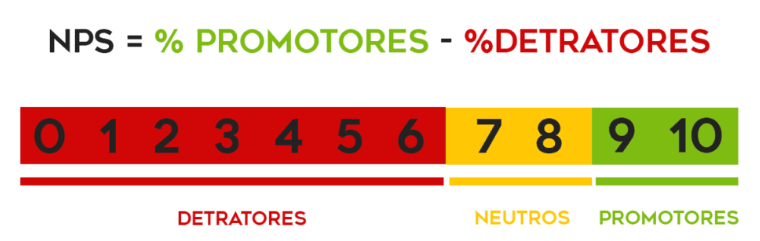




In [42]:
# A funçao categorizar_nps classifica cada cliente da base de acordo
#  com a métrica oficial.

def categorizar_nps(df):
    """Categoriza o NPS com base na coluna nps_score."""
    score = df['nps_score']

    perfil = pd.Series("Detrator", index=df.index)

    return perfil.case_when([
        (score >= 9, "Promotor"),
        (score >= 7, "Neutro")
    ])


df_full_nps['profile_nps'] = categorizar_nps(df_full_nps)
print("5 primeiras linhas com a nova coluna: ")
df_full_nps.head()



5 primeiras linhas com a nova coluna: 


,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,profile_nps
0,172,30,Sudeste,45,50172,139.62,4,5.50,7,8,1,60.85,1,7,1,0.0,0,10,2.4,Detrator
1,462,57,Sul,48,50462,222.50,3,48.65,6,9,5,48.83,2,6,3,0.0,0,10,0.0,Detrator
2,819,40,Norte,22,50819,540.24,3,50.89,2,13,3,62.74,2,4,3,0.0,0,10,2.2,Detrator
3,1861,36,Norte,7,51861,859.15,2,67.46,5,5,3,32.79,2,6,10,0.0,0,10,0.0,Detrator
4,1869,48,Centro-Oeste,65,51869,625.39,1,15.25,3,9,1,36.23,1,6,10,0.0,0,10,0.0,Detrator


In [43]:
print("Distribuição da base de dados")
df_full_nps.profile_nps.value_counts()

Distribuição da base de dados


,count
profile_nps,
Detrator,2109
Neutro,281
Promotor,110


**Passo 3:** Correlação das variaveis da base com o NPS

In [44]:
correlacoes = df_full_nps.corr(numeric_only=True)['nps_score']
correlacoes

,nps_score
customer_id,0.015162
customer_age,-0.009936
customer_tenure_months,-0.009711
order_id,0.015162
order_value,0.036990
items_quantity,0.011468
discount_value,0.025104
payment_installments,0.023718
delivery_time_days,0.000925
delivery_delay_days,-0.597260


In [45]:
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')

In [46]:
# Filtrar correlações mais próximas de +1 ou -1 (excluindo a correlação da própria nps_score com ela mesma)
strong_correlations = correlacoes[(correlacoes.abs() >= 0.5)].drop('nps_score')
if not strong_correlations.empty:
    print("Correlações mais fortes com o NPS (próximas de +1 ou -1):\n")
    print(strong_correlations.sort_values(ascending=False))
else:
    print("Não foram encontradas correlações fortes com o NPS (abs >= 0.5).")


Correlações mais fortes com o NPS (próximas de +1 ou -1):

repeat_purchase_30d    0.570324
csat_internal_score    0.563952
delivery_delay_days   -0.597260
Name: nps_score, dtype: float64


In [47]:
result = df_full_nps.groupby('profile_nps').agg(
    total_clientes=('customer_id', 'count'),
    total_recompras_30d=('repeat_purchase_30d', 'sum'),
    taxa_recompra_percent=('repeat_purchase_30d', 'mean'),
    tempo_medio_relacionamento_meses=('customer_tenure_months', 'mean'),
    media_atraso_entrega=('delivery_delay_days', 'mean'),
    media_contatos_suporte=('customer_service_contacts', 'mean'),
    total_reclamacoes=('complaints_count', 'sum')
)

result['taxa_recompra_percent'] = (result['taxa_recompra_percent'] * 100).round(2)
result['tempo_medio_relacionamento_meses'] = result['tempo_medio_relacionamento_meses'].round(1)
result['media_atraso_entrega'] = result['media_atraso_entrega'].round(2)
result['media_contatos_suporte'] = result['media_contatos_suporte'].round(2)

result

,total_clientes,total_recompras_30d,taxa_recompra_percent,tempo_medio_relacionamento_meses,media_atraso_entrega,media_contatos_suporte,total_reclamacoes
profile_nps,,,,,,,
Detrator,2109,0,0.0,61.4,2.41,1.63,9369
Neutro,281,108,38.43,59.8,1.05,1.01,757
Promotor,110,110,100.0,63.0,0.72,0.67,250


**Passo 4** Visualização da distribuiçao do NPS

In [48]:
df_plot = result.reset_index()

/tmp/ipykernel_99282/875874986.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='profile_nps', y='media_atraso_entrega', palette=colors)


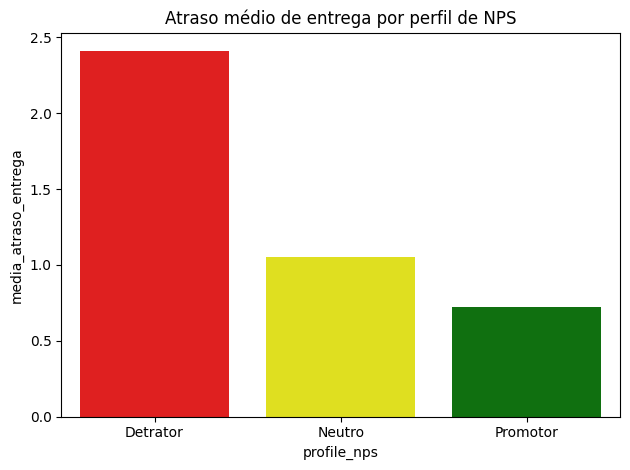

In [49]:
colors = {'Detrator': 'red', 'Neutro': 'yellow', 'Promotor': 'green'}
sns.barplot(data=df_plot, x='profile_nps', y='media_atraso_entrega', palette=colors)
plt.title('Atraso médio de entrega por perfil de NPS')
plt.tight_layout()
plt.show()

/tmp/ipykernel_99282/3367047334.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_plot, x='profile_nps', y='total_reclamacoes', palette=colors)


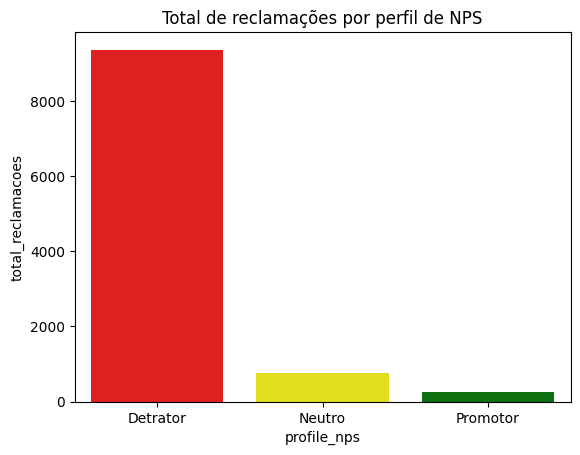

In [50]:
sns.barplot(data=df_plot, x='profile_nps', y='total_reclamacoes', palette=colors)
plt.title('Total de reclamações por perfil de NPS')
plt.show()

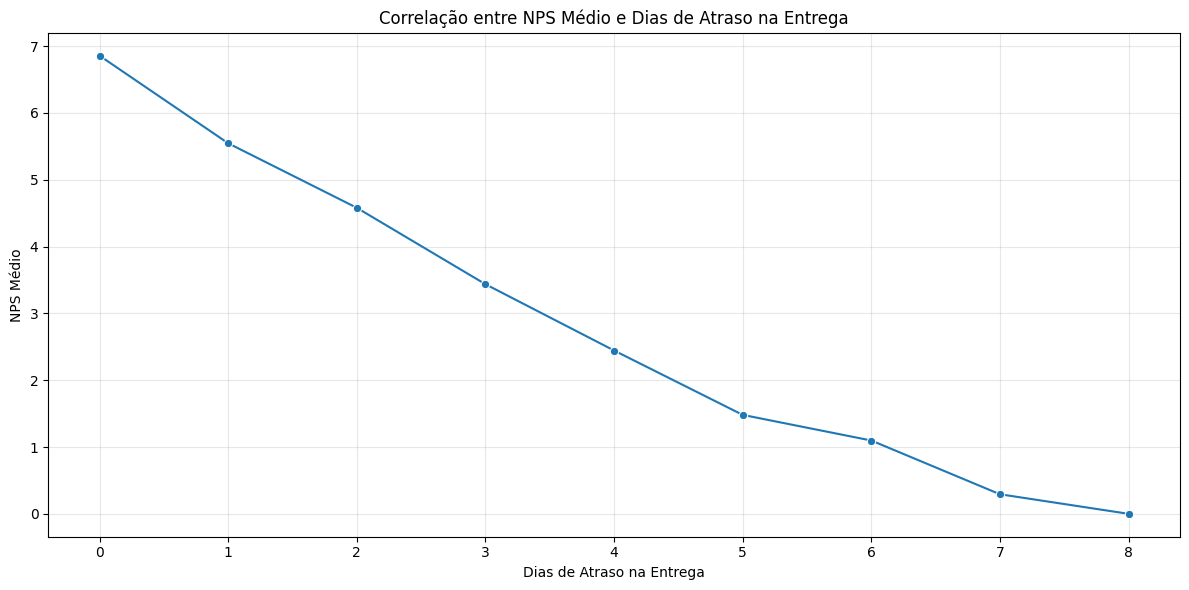

   delivery_delay_days  nps_medio  total_pedidos  taxa_recompra
0                    0   6.856679            277        0.33935
1                    1   5.546179            615       0.147967
2                    2   4.580186            646       0.040248
3                    3   3.436762            525       0.011429
4                    4   2.444444            270       0.003704
5                    5   1.481034            116            0.0
6                    6   1.097059             34            0.0
7                    7   0.292857             14            0.0
8                    8   0.000000              3            0.0


In [51]:
nps_por_atraso = df_full_nps.groupby('delivery_delay_days').agg(
    nps_medio=('nps_score', 'mean'),
    total_pedidos=('order_id', 'count'),
    taxa_recompra=('repeat_purchase_30d', 'mean')
).reset_index()

# Visualização comparando dias de atraso na entrega com o NPS médio
plt.figure(figsize=(12, 6))
sns.lineplot(data=nps_por_atraso, x=nps_por_atraso['delivery_delay_days'], y=nps_por_atraso['nps_medio'], marker='o')
plt.xlabel('Dias de Atraso na Entrega')
plt.ylabel('NPS Médio')
plt.title('Correlação entre NPS Médio e Dias de Atraso na Entrega')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print(nps_por_atraso)

NPS Médio por Região do Cliente:
  customer_region  nps_score
0    Centro-Oeste   4.209829
1        Nordeste   4.421649
2           Norte   4.382609
3         Sudeste   4.373846
4             Sul   4.490979


/tmp/ipykernel_99282/883596143.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=nps_by_region, x='customer_region', y='nps_score', palette='viridis')


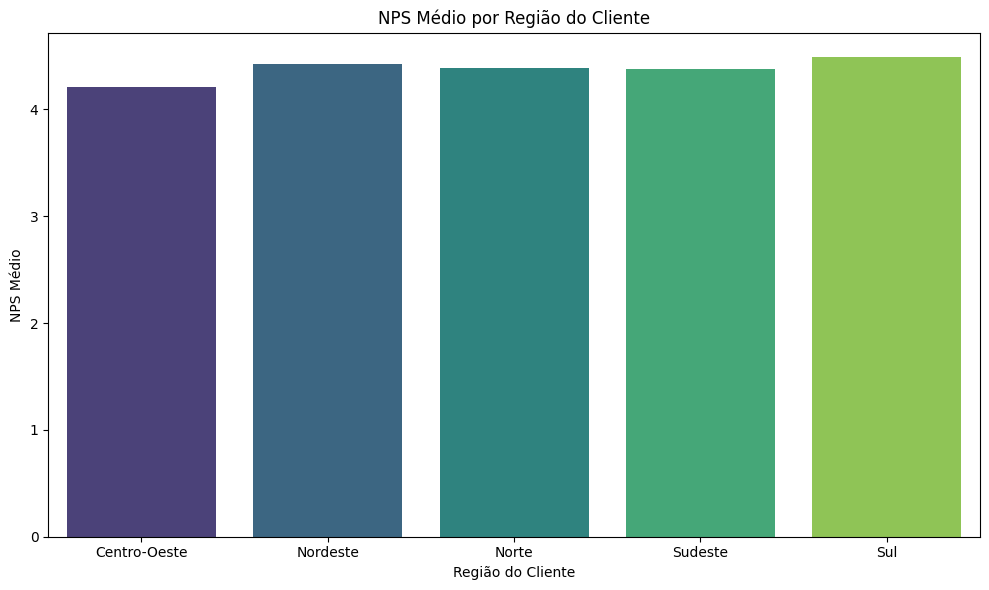

In [52]:
# Visualização comparando o NPS médio por região do cliente
nps_by_region = df_full_nps.groupby('customer_region')['nps_score'].mean().reset_index()
print("NPS Médio por Região do Cliente:")
print(nps_by_region)

plt.figure(figsize=(10, 6))
sns.barplot(data=nps_by_region, x='customer_region', y='nps_score', palette='viridis')
plt.title('NPS Médio por Região do Cliente')
plt.xlabel('Região do Cliente')
plt.ylabel('NPS Médio')
plt.tight_layout()
plt.show()

/tmp/ipykernel_99282/1733141442.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_full_nps, x='customer_region', y='delivery_delay_days', palette='Set2')


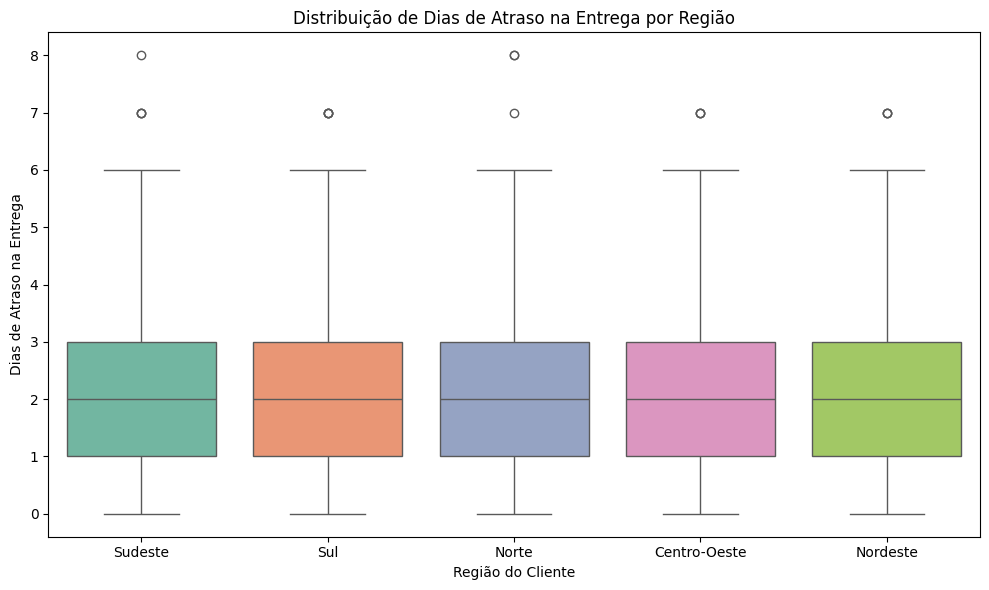

In [53]:
# Visualização comparando dias de atraso na entrega com a região da compra
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_full_nps, x='customer_region', y='delivery_delay_days', palette='Set2')
plt.title('Distribuição de Dias de Atraso na Entrega por Região')
plt.xlabel('Região do Cliente')
plt.ylabel('Dias de Atraso na Entrega')
plt.tight_layout()
plt.show()

/tmp/ipykernel_99282/2558447226.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=faturamento_por_perfil, x='profile_nps', y='order_value', palette=colors)


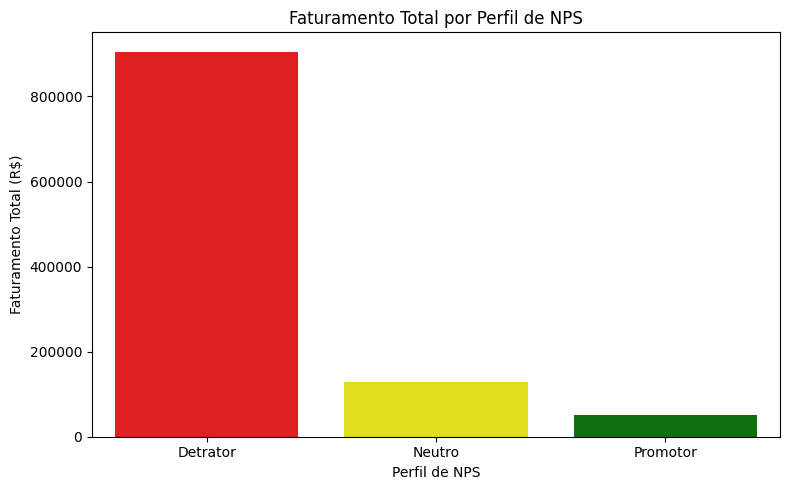

,profile_nps,order_value
0,Detrator,905413.82
1,Neutro,128746.27
2,Promotor,51489.26


In [54]:
# Visualização comparando o faturamento total por perfil de NPS
faturamento_por_perfil = df_full_nps.groupby('profile_nps')['order_value'].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=faturamento_por_perfil, x='profile_nps', y='order_value', palette=colors)
plt.title('Faturamento Total por Perfil de NPS')
plt.xlabel('Perfil de NPS')
plt.ylabel('Faturamento Total (R$)')
plt.tight_layout()
plt.show()
faturamento_por_perfil

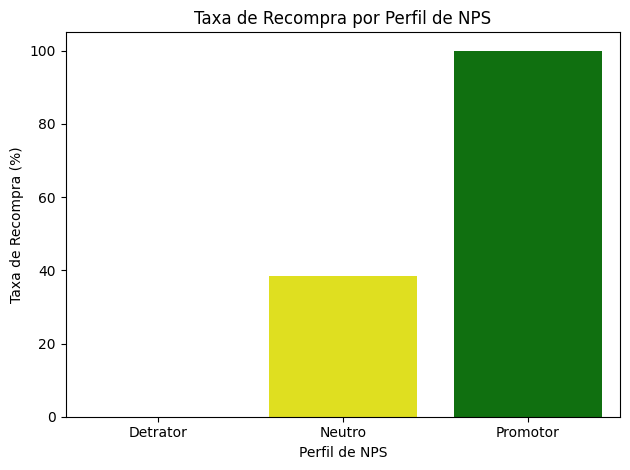

In [55]:
# Visualização comparando a taxa de recompra por perfil de NPS
colors = {'Detrator': 'red', 'Neutro': 'yellow', 'Promotor': 'green'}
sns.barplot(data=df_plot, x='profile_nps', y='taxa_recompra_percent', hue='profile_nps', palette=colors, legend=False)
plt.title('Taxa de Recompra por Perfil de NPS')
plt.xlabel('Perfil de NPS')
plt.ylabel('Taxa de Recompra (%)')
plt.tight_layout()
plt.show()

## Resumo Executivo

Principais descobertas e insights para o negócio.

### 1. Revisão das Análises Realizadas

A partir da análise exploratória de dados (EDA) aprofundada, foi possível descobrir:
-   **Revisão Qualidade dos Dados:** Entendimento da estrutura do `df_full_nps`, tipos de dados, ausência de valores nulos e estatísticas descritivas que forneceram uma visão macro das métricas operacionais e de cliente.
-   **Análise Detalhada dos Perfis de NPS:** Categorização dos clientes em Detratores, Neutros e Promotores e comparação de métricas-chave para cada grupo (recompra, atraso na entrega, contatos de suporte, reclamações, tempo de resolução e CSAT interno).
-   **Investigação dos Principais Impulsionadores:** Identificação da forte correlação negativa entre `delivery_delay_days` e `nps_score`.
-   **Exploração do Impacto Demográfico:** Análise do NPS médio por `customer_region`, que mostrou pouca variação regional.

### 2. Principais Descobertas por Perfil de NPS

#### Detratores (nps_score <= 6)
-   **Maior Volume:** Constituem a maior parte da base de clientes (2109), indicando um problema generalizado de insatisfação.
-   **Fidelidade Zero:** Não realizam recompras (0% taxa de recompra em 30 dias), evidenciando a perda iminente de clientes.
-   **Problemas Operacionais:** Apresentam o maior tempo médio de atraso na entrega (2.41 dias), o maior número de contatos com o suporte (1.63), o maior tempo de resolução de problemas (5.69 dias) e o maior volume de reclamações (9369). Seu CSAT interno é o mais baixo (2.54).
-   **Perigo de Churn:** São os clientes com maior probabilidade de churn e de prejudicar a reputação da marca.

#### Neutros (7 <= nps_score <= 8)
-   **Potencial de Melhoria:** Um grupo significativo (281 clientes) que recompra em uma taxa razoável (38.43%), mas não é engajado o suficiente para ser promotor.
-   **Experiência Intermediária:** Têm atrasos na entrega menores que os detratores (1.05 dias), menos contatos com o suporte (1.01) e um tempo de resolução de problemas e CSAT interno em níveis intermediários. Ainda geram um número considerável de reclamações (757).
-   **Oportunidade de Conversão:** Pequenas melhorias na experiência podem transformá-los em promotores.

#### Promotores (nps_score >= 9)
-   **Base Fiel:** O menor grupo (110 clientes), mas o mais valioso.
-   **Fidelidade Total:** 100% de taxa de recompra em 30 dias, demonstrando lealdade e engajamento.
-   **Experiência Excelente:** Têm os menores atrasos na entrega (0.72 dias), menos contatos com o suporte (0.67), tempo de resolução de problemas eficiente (3.70 dias) e o maior CSAT interno (6.04). O volume de reclamações é mínimo (250).
-   **Advogados da Marca:** São os clientes que recomendam a empresa e contribuem para o crescimento orgânico.

### 3. Variável de Maior Impacto no NPS: `delivery_delay_days`

A correlação de -0.59726 entre `delivery_delay_days` e `nps_score` é a mais forte identificada. Isso significa que **a pontualidade na entrega é o fator isolado mais crítico para a satisfação do cliente e, consequentemente, para o NPS**.

**Implicação:** Atrasos na entrega não apenas frustram os clientes, mas são um gatilho direto para a insatisfação, transformando clientes em Detratores e resultando em perda de recompras, aumento de contatos com o suporte e maior volume de reclamações. A logística eficiente é, portanto, um pilar fundamental para a saúde do negócio e a fidelização do cliente.

### 4. Insights de Negócio Acionáveis

1.  **Reatividade Operacional é Custosa:** A empresa está perdendo clientes e dinheiro porque só descobre a insatisfação quando o dano já é grande. A grande quantidade de Detratores e a ausência de recompra neste grupo é uma prova clara disso. A proatividade é essencial. Além disso o faturamento total dos detratores foi no valor de **R$905.413,82**
2.  **Logística é Satisfação:** A pontualidade da entrega não é apenas um custo operacional, mas um driver central de satisfação e fidelidade. Investir em melhorias logísticas se traduz diretamente em um NPS maior e, consequentemente, em mais recompras.
3.  **Suporte como Sintoma, Não Causa:** O alto volume de contatos e reclamações dos Detratores e Neutros indica que o suporte está lidando com problemas recorrentes e sistêmicos, e não apenas com questões pontuais. O foco deve ser na prevenção de problemas que geram a necessidade de contato.
4.  **O Potencial dos Neutros:** Os Neutros representam uma oportunidade significativa de crescimento. Eles já têm algum nível de fidelidade (compram novamente), e pequenas melhorias podem convertê-los em Promotores, que são os mais rentáveis.

### 5. Recomendações Acionáveis e Estratégias

1.  **Priorizar a Otimização da Logística (Foco em `delivery_delay_days`):**
    -   **Meta:** Reduzir a média de `delivery_delay_days` para os níveis dos Promotores (abaixo de 1 dia).
    -   **Ações:** Investir em tecnologias de rastreamento e previsão de entrega, otimizar rotas de entrega, negociar com transportadoras para garantir SLAs mais rigorosos, e estabelecer um sistema de alerta proativo para atrasos, informando os clientes antes que eles precisem entrar em contato.
    -   **Áreas Beneficiadas:** Logística, Atendimento ao Cliente.

2.  **Desenvolver Estratégias de Retenção para Detratores:**
    -   **Meta:** Reduzir o número de Detratores e evitar o churn.
    -   **Ações:** Identificar proativamente clientes em risco (com base em `delivery_delay_days`, `customer_service_contacts`, `complaints_count`) e implementar campanhas de reengajamento com ofertas personalizadas, contato proativo para resolução de problemas e pesquisas de satisfação focadas na causa raiz da insatisfação.
    -   **Áreas Beneficiadas:** CRM, Atendimento ao Cliente, Marketing.

3.  **Estratégias de Conversão para Neutros:**
    -   **Meta:** Transformar Neutros em Promotores.
    -   **Ações:** Realizar pesquisas de satisfação específicas para Neutros para entender o que falta em sua experiência. Oferecer benefícios exclusivos, programas de fidelidade, e garantir que suas próximas experiências de compra e entrega sejam impecáveis. Focar em melhorias que os levem de uma boa experiência a uma excelente experiência.
    -   **Áreas Beneficiadas:** Marketing, CRM, Produto.

4.  **Fortalecer o Atendimento ao Cliente como Prevenção:**
    -   **Meta:** Reduzir a necessidade de contato reativo e o tempo de resolução.
    -   **Ações:** Capacitar a equipe de suporte para identificar padrões de problemas e reportar proativamente para outras áreas (logística, produto). Melhorar canais de autoatendimento (FAQs, chatbots inteligentes) para que clientes possam resolver problemas básicos sem intervenção humana. Reduzir o tempo médio de resolução para todos os perfis.
    -   **Áreas Beneficiadas:** Atendimento ao Cliente, TI.

5.  **Manter e Alavancar Promotores:**
    -   **Meta:** Garantir a continuidade da lealdade e incentivar a recomendação.
    -   **Ações:** Reconhecer e recompensar Promotores através de programas de indicação, acesso antecipado a produtos, ou ofertas exclusivas. Continuar a monitorar sua satisfação para garantir que os padrões de serviço se mantenham elevados.
    -   **Áreas Beneficiadas:** Marketing, CRM.

